In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, logistic_regression_path
from sklearn.metrics import mean_squared_error
from google.colab import files
files=files.upload()


Saving logit_insurance(1).csv to logit_insurance(1) (2).csv


In [ ]:
import statistics
from numpy import nan
import io
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(io.BytesIO(files['logit_insurance(1).csv']))
df=df.drop(['INDEX'],axis=1)
df.describe(include='all')

In [ ]:
# impute missing values with the mean for YOJ
df['YOJ']=df['YOJ'].fillna(np.nanmean(df['YOJ']))
np.nanmean(df['YOJ'])
# impute missing values with the mean for AGE
df['AGE']=df['AGE'].fillna(np.nanmean(df['AGE']))
df['AGE']
# impute missing values with the mean for CAR_AGE
df['CAR_AGE']=df['CAR_AGE'].fillna(np.nanmean(df['CAR_AGE']))
df["CAR_AGE"][df['CAR_AGE']<0]=0


In [ ]:
# Replace NaN in job with Unknown
df['JOB']=df['JOB'].fillna("Unknown")

# impute missing value in the income column with the mean of the particular job

Professional_inc=df['INCOME'][df['JOB']=='Professional']
df['INCOME'][df['JOB']=='Professional'] = df['INCOME'][df['JOB']=='Professional'].fillna(np.nanmean(Professional_inc))

Blue_inc=df['INCOME'][df['JOB']=='z_Blue Collar']
df['INCOME'][df['JOB']=='z_Blue Collar']= df['INCOME'][df['JOB']=='z_Blue Collar'].fillna(np.nanmean(Blue_inc))

Clerical_inc=df['INCOME'][df['JOB']=='Clerical']
df['INCOME'][df['JOB']=='Clerical'] = df['INCOME'][df['JOB']=='Clerical'].fillna(np.nanmean(Clerical_inc))


Doctor_inc=df['INCOME'][df['JOB']=='Doctor']
df['INCOME'][df['JOB']=='Doctor'] = df['INCOME'][df['JOB']=='Doctor'].fillna(np.nanmean(Doctor_inc))

Lawyer_inc=df['INCOME'][df['JOB']=='Lawyer']
df['INCOME'][df['JOB']=='Lawyer'] = df['INCOME'][df['JOB']=='Lawyer'].fillna(np.nanmean(Lawyer_inc))

Manager_inc=df['INCOME'][df['JOB']=='Manager']
df['INCOME'][df['JOB']=='Manager'] = df['INCOME'][df['JOB']=='Manager'].fillna(np.nanmean(Manager_inc))

HM_inc=df['INCOME'][df['JOB']=='Home Maker']
df['INCOME'][df['JOB']=='Home Maker'] = df['INCOME'][df['JOB']=='Home Maker'].fillna(np.nanmean(HM_inc))

Student_inc=df['INCOME'][df['JOB']=='Student']
df['INCOME'][df['JOB']=='Student'] = df['INCOME'][df['JOB']=='Student'].fillna(np.nanmean(Student_inc))
# If Job is unknown, impute the missing income with the mean value of income in general

df['INCOME'][df['JOB']=='Unknown'] = df['INCOME'][df['JOB']=='Unknown'].fillna(np.nanmean(df['INCOME']))

In [ ]:
# handle outliers which greater than Q3+1.5IQR
for i in ['AGE', 'HOMEKIDS', 'YOJ','TRAVTIME', 'BLUEBOOK', 'TIF','OLDCLAIM','CLM_FREQ', 'MVR_PTS', 'CAR_AGE']:
  Q1=np.percentile(df[i],25)
  Q2=np.percentile(df[i],50)
  Q3=np.percentile(df[i],75)
  IQR=Q3-Q1
  df[i][df[i]>Q3+1.5*IQR]=Q3+1.5*IQR

In [ ]:
# Bin age by "Young","Middle_Age" and"Old"
age_labels=["Young","Middle_Age","Old"]
age_bins = [16,25,60,np.inf]
df['bin_AGE'] = pd.cut(df['AGE'] , bins=age_bins, labels=age_labels, include_lowest=True)

In [ ]:
labels=["No_Income", "Poor", "Lower_Middle","Middle","Upper_Middle","Rich"]
bins = [0, 1, 32048, 53413, 106827, 200000, np.inf]
df['bin_INCOME'] = pd.cut(df['INCOME'] , bins=bins, labels=labels, include_lowest=True)
# plt.hist(df['bin_INCOME'], bins=6)
# plt.show()

In [ ]:
No_Income_HV=Poor_HV=df['HOME_VAL'][df['bin_INCOME']=='No_Income']
df['HOME_VAL'][df['bin_INCOME']=='No_Income'] = df['HOME_VAL'][df['bin_INCOME']=='No_Income'].fillna(np.nanmean(No_Income_HV))
Poor_HV=df['HOME_VAL'][df['bin_INCOME']=='Poor']
df['HOME_VAL'][df['bin_INCOME']=='Poor'] = df['HOME_VAL'][df['bin_INCOME']=='Poor'].fillna(np.nanmean(Poor_HV))
Low_middle_HV=df['HOME_VAL'][df['bin_INCOME']=='Lower_Middle']
df['HOME_VAL'][df['bin_INCOME']=='Lower_Middle'] = df['HOME_VAL'][df['bin_INCOME']=='Lower_Middle'].fillna(np.nanmean(Low_middle_HV))
Middle_HV=df['HOME_VAL'][df['bin_INCOME']=='Middle']
df['HOME_VAL'][df['bin_INCOME']=='Middle'] = df['HOME_VAL'][df['bin_INCOME']=='Middle'].fillna(np.nanmean(Middle_HV))
Upper_middle_HV=df['HOME_VAL'][df['bin_INCOME']=='Upper_Middle']
df['HOME_VAL'][df['bin_INCOME']=='Upper_Middle'] = df['HOME_VAL'][df['bin_INCOME']=='Upper_Middle'].fillna(np.nanmean(Upper_middle_HV))
Rich_HV=df['HOME_VAL'][df['bin_INCOME']=='Rich']
df['HOME_VAL'][df['bin_INCOME']=='Rich'] = df['HOME_VAL'][df['bin_INCOME']=='Rich'].fillna(np.nanmean(Rich_HV))


In [ ]:
Home_labels=["No_home","level1","level2","level3","level4","level5"]
Home_bins=[0, 1, 99999, 200000,300000, 400000, np.inf]
df['bin_HOME_VAL'] = pd.cut(df['HOME_VAL'] , bins=Home_bins, labels=Home_labels, include_lowest=True)
# plt.hist(df['bin_HOME_VAL'], bins=6)
# plt.show()


In [ ]:

# mapping categorical data into 1 and 0
dic_parent1={"No":0,"Yes":1}
for i in range(len(df['PARENT1'])):
  if df['PARENT1'][i]=="Yes":
    df['PARENT1'][i]=1
  if df['PARENT1'][i]=="No":
    df['PARENT1'][i]=0
dic_MSTATUS={"z_No":1,"Yes":0}
for i in range(len(df['PARENT1'])):
  if df['MSTATUS'][i]=='z_No':
    df['MSTATUS'][i]=1
  if df['MSTATUS'][i]=='Yes':
    df['MSTATUS'][i]=0
dic_SEX={"M":1,'z_F':0}
for i in range(len(df['SEX'])):
  if df['SEX'][i]=='z_F':
    df['SEX'][i]=0
  else:
    df['SEX'][i]=1

dic_CARUSE={'Commercial':1,'Private':0}
for i in range(len(df['CAR_USE'])):
  if df['CAR_USE'][i]=='Commercial':
    df['CAR_USE'][i]=1
  if df['CAR_USE'][i]=='Private':
    df['CAR_USE'][i]=0
X = df.loc[:,(df.columns!='TARGET_FLAG') & (df.columns!='TARGET_FLAG')]
Y = df['TARGET_FLAG'].values

dic_CARTYPE={'Minivan', 'z_SUV', 'Sports Car', 'Van', 'Panel Truck', 'Pickup'}

dic_URBANICITY={'Highly Urban/ Urban':0,'z_Highly Rural/ Rural':1}
for i in range(len(df['URBANICITY'])):
  if df['URBANICITY'][i]=='Highly Urban/ Urban':
    df['URBANICITY'][i]=0
  if df['URBANICITY'][i]=='z_Highly Rural/ Rural':
    df['URBANICITY'][i]=1

dic_REVOKED={'No':0,'Yes':1}
for i in range(len(df['REVOKED'])):
  if df['REVOKED'][i]=='No':
    df['REVOKED'][i]=0
  if df['REVOKED'][i]=='Yes':
    df['REVOKED'][i]=1

dic_RED={'no':0,'yes':1}
for i in range(len(df['RED_CAR'])):
  if df['RED_CAR'][i]=='no':
    df['RED_CAR'][i]=0
  if df['RED_CAR'][i]=='yes':
    df['RED_CAR'][i]=1









In [ ]:
CARTYPE=['Minivan', 'z_SUV', 'Sports Car', 'Van', 'Panel Truck', 'Pickup']
dum_df = pd.get_dummies(df["CAR_TYPE"] )
# merge with main df on key values
df = df.join(dum_df)
df=df.drop(['CAR_TYPE'],axis=1)
JOBTYPE=['Professional', 'z_Blue Collar', 'Clerical', 'Doctor', 'Lawyer', 'Manager', 'Home Maker', 'Student', 'Unknown']
job_df = pd.get_dummies(df["JOB"])
df=df.drop(['JOB'],axis=1)
# merge with main df on key values
df = df.join(job_df)

edu_df = pd.get_dummies(df["EDUCATION"])
df=df.drop(['EDUCATION'],axis=1)
# merge with main df on key values
df = df.join(edu_df)

home_df = pd.get_dummies(df['bin_HOME_VAL'])
df=df.drop(['bin_HOME_VAL'],axis=1)
df=df.drop(['HOME_VAL'],axis=1)
# merge with main df on key values
df = df.join(home_df)

income_df = pd.get_dummies(df['bin_INCOME'])
df=df.drop(['bin_INCOME'],axis=1)
df=df.drop(['INCOME'],axis=1)
# merge with main df on key values
df = df.join(income_df)

age_df = pd.get_dummies(df['bin_AGE'])
df=df.drop(['bin_AGE'],axis=1)
df=df.drop(['AGE'],axis=1)
# merge with main df on key values
df = df.join(age_df)



In [ ]:
# telling python which ones are cetegorical value
df['PARENT1'] = df['PARENT1'].astype('category')
df['MSTATUS'] = df['MSTATUS'].astype('category')
df['SEX'] = df['SEX'].astype('category')
df['CAR_USE'] = df['CAR_USE'].astype('category')
df['RED_CAR'] = df['RED_CAR'].astype('category')
df['REVOKED'] = df['REVOKED'].astype('category')
df['URBANICITY']=df['URBANICITY'].astype('category')
df['No_home']=df['No_home'].astype('category')

In [ ]:
df[['Professional', 'z_Blue Collar', 'Clerical', 'Doctor', 'Lawyer', 'Manager', 'Home Maker', 'Student', 'Unknown']]=df[['Professional', 'z_Blue Collar', 'Clerical', 'Doctor', 'Lawyer', 'Manager', 'Home Maker', 'Student', 'Unknown']].astype('category')
df[['Minivan', 'z_SUV', 'Sports Car', 'Van', 'Panel Truck', 'Pickup']]=df[['Minivan', 'z_SUV', 'Sports Car', 'Van', 'Panel Truck', 'Pickup']].astype('category')
df[['No_home','level1','level2','level3','level4','level5',	'No_Income',	'Poor',	'Lower_Middle',	'Middle',	'Upper_Middle',	'Rich']]=df[['No_home','level1',	'level2',	'level3',	'level4',	'level5',	'No_Income',	'Poor',	'Lower_Middle',	'Middle',	'Upper_Middle',	'Rich']].astype('category')
df[['PhD', 'z_High School', '<High School', 'Bachelors', 'Masters']]=df[['PhD', 'z_High School', '<High School', 'Bachelors', 'Masters']].astype('category')
df[['Young','Old']]=df[['Young','Old']].astype('category')

In [ ]:
# model one: logiestic regression with all features
Y1 = df['TARGET_FLAG'].values
X1 = df.loc[:,(df.columns!='TARGET_FLAG') & (df.columns!='TARGET_FLAG')]
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size = 0.2,random_state=11)

In [ ]:
THRESHOLD=0.35
model1= LogisticRegression(solver='newton-cg',max_iter=10000)
model1.fit(X_train1,Y_train1)
Y_pred1 = np.where(model1.predict_proba(X_test1)[:,1] > THRESHOLD, 1, 0)

In [ ]:
model1.score(X_test1, Y_test1)

0.7979179424372321

In [ ]:
import statsmodels.api as sm
model1_result = sm.Logit(endog=Y_train1, exog=X_train1.astype(float)).fit()
print(model1_result.summary())

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix=confusion_matrix(Y_test1, Y_pred1)
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')
 
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title(' Model1 Confusion Matrix at 0.2test_size', fontsize=18)
plt.show()

In [ ]:
df2=df.copy()
df2=df2.drop(['SEX','YOJ','Middle_Age','RED_CAR','CAR_AGE','HOMEKIDS'],axis=1)
df2=df2.drop(['Unknown'],axis=1)
df2=df2.drop(['Poor','Pickup','PhD'],axis=1)
df2=df2.drop(['OLDCLAIM'],axis=1)
Y2 = df2['TARGET_FLAG'].values
X2 = df2.loc[:,(df2.columns!='TARGET_FLAG') & (df2.columns!='TARGET_FLAG')]

In [ ]:
model2= LogisticRegression(solver='newton-cg',max_iter=10000)
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X2, Y2, test_size = 0.2,random_state=11)
model2.fit(X_train2,Y_train2)
Y_pred2 = np.where(model2.predict_proba(X_test2)[:,1] > THRESHOLD, 1, 0)

In [ ]:
model2.score(X_test2, Y_test2)

0.8022045315370484

In [ ]:
model2_result = sm.Logit(endog=Y_train2, exog=X_train2.astype(float)).fit()
print(model2_result.summary())

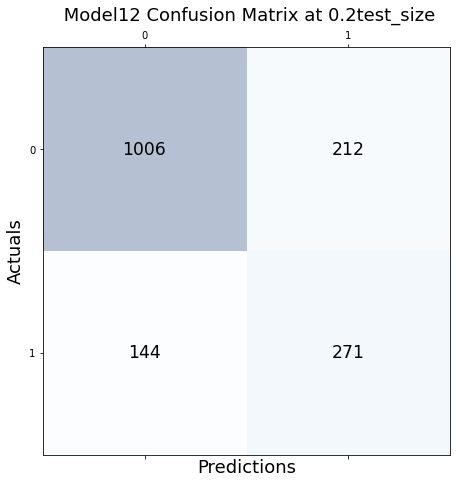

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix2=confusion_matrix(Y_test2, Y_pred2)
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(conf_matrix2, cmap=plt.cm.Blues, alpha=0.3)
for i in range(conf_matrix2.shape[0]):
    for j in range(conf_matrix2.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix2[i, j], va='center', ha='center', size='xx-large')
 
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title(' Model12 Confusion Matrix at 0.2test_size', fontsize=18)
plt.show()

In [ ]:
# model3 building interaction terms based on some factors that insurance company may be interested in:
# Young Male; Unmarried Male; poeple with no income and has been revoked;Commerical used sports car.
df3=df.copy()

In [ ]:
df3['YoungMale']=df3['SEX'].astype("uint8")*df3['Young'].astype("uint8")
df3['YoungMale'].astype("category")
df3['UnmarriedMale']=df3['MSTATUS'].astype("uint8")*df3['SEX'].astype("uint8")
df3['UnmarriedMale'].astype("category")
df3['RevokedNoincome']=df3['REVOKED'].astype("uint8")*df3['No_Income'].astype("uint8")
df3['RevokedNoincome'].astype("category")
df3['CommercialSportsCar']=df3['CAR_USE'].astype("uint8")*df3['Sports Car'].astype("uint8")
df3['CommercialSportsCar'].astype("category")
df3=df3.drop(['SEX','YOJ','Middle_Age','RED_CAR','CAR_AGE','HOMEKIDS'],axis=1)
df3=df3.drop(['Unknown'],axis=1)
df3=df3.drop(['Poor','Pickup','PhD'],axis=1)
df3=df3.drop(['OLDCLAIM'],axis=1)
Y3 = df3['TARGET_FLAG'].values
X3 = df3.loc[:,(df3.columns!='TARGET_FLAG') & (df3.columns!='TARGET_FLAG')]
model3= LogisticRegression(solver='newton-cg',max_iter=10000)
X_train3, X_test3, Y_train3, Y_test3 = train_test_split(X3, Y3, test_size = 0.2,random_state=11)
model3.fit(X_train3,Y_train3)
Y_pred3 = np.where(model3.predict_proba(X_test3)[:,1] > THRESHOLD, 1, 0)

In [ ]:
print(model3.predict_proba(X_test3))

[[0.94274747 0.05725253]
 [0.94688183 0.05311817]
 [0.94889604 0.05110396]
 ...
 [0.94613419 0.05386581]
 [0.82561397 0.17438603]
 [0.48642684 0.51357316]]


In [ ]:
model3.score(X_test3, Y_test3)

0.8022045315370484

In [ ]:
Y_pred3 = pd.DataFrame(Y_pred3, columns=['predictions']).to_csv('prediction.csv')
from google.colab import files
files.download("prediction.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model3_result = sm.Logit(endog=Y_train3, exog=X_train3.astype(float)).fit()
print(model3_result.summary())

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix3=confusion_matrix(Y_test3, Y_pred3)
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(conf_matrix3, cmap=plt.cm.Blues, alpha=0.3)
for i in range(conf_matrix3.shape[0]):
    for j in range(conf_matrix3.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix3[i, j], va='center', ha='center', size='xx-large')
 
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title(' Model3 Confusion Matrix at 0.2test_size', fontsize=18)
plt.show()

In [ ]:
# Rebuild Model3 to predict Test Dataset

In [ ]:
df_train=df.copy()
df_train['YoungMale']=df_train['SEX'].astype("uint8")*df_train['Young'].astype("uint8")
df_train['YoungMale'].astype("category")
df_train['UnmarriedMale']=df_train['MSTATUS'].astype("uint8")*df_train['SEX'].astype("uint8")
df_train['UnmarriedMale'].astype("category")
df_train['RevokedNoincome']=df_train['REVOKED'].astype("uint8")*df_train['No_Income'].astype("uint8")
df_train['RevokedNoincome'].astype("category")
df_train['CommercialSportsCar']=df_train['CAR_USE'].astype("uint8")*df_train['Sports Car'].astype("uint8")
df_train['CommercialSportsCar'].astype("category")
df_train=df_train.drop(['SEX','YOJ','Middle_Age','RED_CAR','CAR_AGE','HOMEKIDS'],axis=1)
df_train=df_train.drop(['Unknown'],axis=1)
df_train=df_train.drop(['Poor','Pickup','PhD'],axis=1)
df_train=df_train.drop(['OLDCLAIM'],axis=1)
Y = df_train['TARGET_FLAG'].values
X = df_train.loc[:,(df_train.columns!='TARGET_FLAG') & (df_train.columns!='TARGET_FLAG')]


In [ ]:
model= LogisticRegression(solver='newton-cg',max_iter=10000)
model.fit(X,Y)

In [ ]:
from google.colab import files
files=files.upload()
test_df = pd.read_csv(io.BytesIO(files['logit_insurance_test(1).csv']))
test_df=test_df.drop(['INDEX'],axis=1)
test_df.describe(include='all')

In [ ]:
# ###DATA PREPERATION FOR TEST DATASET


# impute missing values with the mean for YOJ
test_df['YOJ']=test_df['YOJ'].fillna(np.nanmean(test_df['YOJ']))
np.nanmean(test_df['YOJ'])
# impute missing values with the mean for AGE
test_df['AGE']=test_df['AGE'].fillna(np.nanmean(test_df['AGE']))

# impute missing values with the mean for CAR_AGE
test_df['CAR_AGE']=test_df['CAR_AGE'].fillna(np.nanmean(test_df['CAR_AGE']))
test_df["CAR_AGE"][test_df['CAR_AGE']<0]=0
# Replace NaN in job with Unknown
test_df['JOB']=test_df['JOB'].fillna("Unknown")

# impute missing value in the income column with the mean of the particular job

Professional_inc=test_df['INCOME'][test_df['JOB']=='Professional']
test_df['INCOME'][test_df['JOB']=='Professional'] = test_df['INCOME'][test_df['JOB']=='Professional'].fillna(np.nanmean(Professional_inc))

Blue_inc=test_df['INCOME'][test_df['JOB']=='z_Blue Collar']
test_df['INCOME'][test_df['JOB']=='z_Blue Collar']= test_df['INCOME'][test_df['JOB']=='z_Blue Collar'].fillna(np.nanmean(Blue_inc))

Clerical_inc=test_df['INCOME'][test_df['JOB']=='Clerical']
test_df['INCOME'][test_df['JOB']=='Clerical'] = test_df['INCOME'][test_df['JOB']=='Clerical'].fillna(np.nanmean(Clerical_inc))


Doctor_inc=test_df['INCOME'][test_df['JOB']=='Doctor']
test_df['INCOME'][test_df['JOB']=='Doctor'] = test_df['INCOME'][test_df['JOB']=='Doctor'].fillna(np.nanmean(Doctor_inc))

Lawyer_inc=test_df['INCOME'][test_df['JOB']=='Lawyer']
test_df['INCOME'][test_df['JOB']=='Lawyer'] = test_df['INCOME'][test_df['JOB']=='Lawyer'].fillna(np.nanmean(Lawyer_inc))

Manager_inc=test_df['INCOME'][test_df['JOB']=='Manager']
test_df['INCOME'][test_df['JOB']=='Manager'] = test_df['INCOME'][test_df['JOB']=='Manager'].fillna(np.nanmean(Manager_inc))

HM_inc=test_df['INCOME'][test_df['JOB']=='Home Maker']
test_df['INCOME'][test_df['JOB']=='Home Maker'] = test_df['INCOME'][test_df['JOB']=='Home Maker'].fillna(np.nanmean(HM_inc))

Student_inc=test_df['INCOME'][test_df['JOB']=='Student']
test_df['INCOME'][test_df['JOB']=='Student'] = test_df['INCOME'][test_df['JOB']=='Student'].fillna(np.nanmean(Student_inc))
# If Job is unknown, impute the missing income with the mean value of income in general

test_df['INCOME'][test_df['JOB']=='Unknown'] = test_df['INCOME'][test_df['JOB']=='Unknown'].fillna(np.nanmean(test_df['INCOME']))
# handle outliers which greater than Q3+1.5IQR
for i in ['AGE', 'HOMEKIDS', 'YOJ','TRAVTIME', 'BLUEBOOK', 'TIF','OLDCLAIM','CLM_FREQ', 'MVR_PTS', 'CAR_AGE']:
  Q1=np.percentile(test_df[i],25)
  Q2=np.percentile(test_df[i],50)
  Q3=np.percentile(test_df[i],75)
  IQR=Q3-Q1
  test_df[i][test_df[i]>Q3+1.5*IQR]=Q3+1.5*IQR
# Bin age by "Young","Middle_Age" and"Old"
age_labels=["Young","Middle_Age","Old"]
age_bins = [16,25,60,np.inf]
test_df['bin_AGE'] = pd.cut(test_df['AGE'] , bins=age_bins, labels=age_labels, include_lowest=True)
labels=["No_Income", "Poor", "Lower_Middle","Middle","Upper_Middle","Rich"]
bins = [0, 1, 32048, 53413, 106827, 200000, np.inf]
test_df['bin_INCOME'] = pd.cut(test_df['INCOME'] , bins=bins, labels=labels, include_lowest=True)
# plt.hist(df['bin_INCOME'], bins=6)
# plt.show()
No_Income_HV=Poor_HV=test_df['HOME_VAL'][test_df['bin_INCOME']=='No_Income']
test_df['HOME_VAL'][test_df['bin_INCOME']=='No_Income'] = test_df['HOME_VAL'][test_df['bin_INCOME']=='No_Income'].fillna(np.nanmean(No_Income_HV))
Poor_HV=test_df['HOME_VAL'][test_df['bin_INCOME']=='Poor']
test_df['HOME_VAL'][test_df['bin_INCOME']=='Poor'] = test_df['HOME_VAL'][test_df['bin_INCOME']=='Poor'].fillna(np.nanmean(Poor_HV))
Low_middle_HV=test_df['HOME_VAL'][test_df['bin_INCOME']=='Lower_Middle']
test_df['HOME_VAL'][test_df['bin_INCOME']=='Lower_Middle'] = test_df['HOME_VAL'][test_df['bin_INCOME']=='Lower_Middle'].fillna(np.nanmean(Low_middle_HV))
Middle_HV=test_df['HOME_VAL'][test_df['bin_INCOME']=='Middle']
test_df['HOME_VAL'][test_df['bin_INCOME']=='Middle'] = test_df['HOME_VAL'][test_df['bin_INCOME']=='Middle'].fillna(np.nanmean(Middle_HV))
Upper_middle_HV=test_df['HOME_VAL'][test_df['bin_INCOME']=='Upper_Middle']
test_df['HOME_VAL'][test_df['bin_INCOME']=='Upper_Middle'] = test_df['HOME_VAL'][test_df['bin_INCOME']=='Upper_Middle'].fillna(np.nanmean(Upper_middle_HV))
Rich_HV=test_df['HOME_VAL'][test_df['bin_INCOME']=='Rich']
test_df['HOME_VAL'][test_df['bin_INCOME']=='Rich'] = test_df['HOME_VAL'][test_df['bin_INCOME']=='Rich'].fillna(np.nanmean(Rich_HV))
Home_labels=["No_home","level1","level2","level3","level4","level5"]
Home_bins=[0, 1, 99999, 200000,300000, 400000, np.inf]
test_df['bin_HOME_VAL'] = pd.cut(test_df['HOME_VAL'] , bins=Home_bins, labels=Home_labels, include_lowest=True)

# mapping categorical data into numerical
dic_parent1={"No":0,"Yes":1}
for i in range(len(test_df['PARENT1'])):
  if test_df['PARENT1'][i]=="Yes":
    test_df['PARENT1'][i]=1
  if test_df['PARENT1'][i]=="No":
    test_df['PARENT1'][i]=0
dic_MSTATUS={"z_No":1,"Yes":0}
for i in range(len(test_df['PARENT1'])):
  if test_df['MSTATUS'][i]=='z_No':
    test_df['MSTATUS'][i]=1
  if test_df['MSTATUS'][i]=='Yes':
    test_df['MSTATUS'][i]=0
dic_SEX={"M":1,'z_F':0}
for i in range(len(test_df['SEX'])):
  if test_df['SEX'][i]=='z_F':
    test_df['SEX'][i]=0
  else:
    test_df['SEX'][i]=1

dic_CARUSE={'Commercial':1,'Private':0}
for i in range(len(test_df['CAR_USE'])):
  if test_df['CAR_USE'][i]=='Commercial':
    test_df['CAR_USE'][i]=1
  if test_df['CAR_USE'][i]=='Private':
    test_df['CAR_USE'][i]=0


dic_CARTYPE={'Minivan', 'z_SUV', 'Sports Car', 'Van', 'Panel Truck', 'Pickup'}

dic_URBANICITY={'Highly Urban/ Urban':0,'z_Highly Rural/ Rural':1}
for i in range(len(test_df['URBANICITY'])):
  if test_df['URBANICITY'][i]=='Highly Urban/ Urban':
    test_df['URBANICITY'][i]=0
  if test_df['URBANICITY'][i]=='z_Highly Rural/ Rural':
    test_df['URBANICITY'][i]=1

dic_REVOKED={'No':0,'Yes':1}
for i in range(len(test_df['REVOKED'])):
  if test_df['REVOKED'][i]=='No':
    test_df['REVOKED'][i]=0
  if test_df['REVOKED'][i]=='Yes':
    test_df['REVOKED'][i]=1

dic_RED={'no':0,'yes':1}
for i in range(len(test_df['RED_CAR'])):
  if test_df['RED_CAR'][i]=='no':
    test_df['RED_CAR'][i]=0
  if test_df['RED_CAR'][i]=='yes':
    test_df['RED_CAR'][i]=1

CARTYPE=['Minivan', 'z_SUV', 'Sports Car', 'Van', 'Panel Truck', 'Pickup']
dum_df = pd.get_dummies(test_df["CAR_TYPE"] )
# merge with main df on key values
test_df = test_df.join(dum_df)
test_df=test_df.drop(['CAR_TYPE'],axis=1)
JOBTYPE=['Professional', 'z_Blue Collar', 'Clerical', 'Doctor', 'Lawyer', 'Manager', 'Home Maker', 'Student', 'Unknown']
job_df = pd.get_dummies(test_df["JOB"])
test_df=test_df.drop(['JOB'],axis=1)
# merge with main df on key values
test_df = test_df.join(job_df)

edu_df = pd.get_dummies(test_df["EDUCATION"])
test_df=test_df.drop(['EDUCATION'],axis=1)
# merge with main df on key values
test_df = test_df.join(edu_df)

home_df = pd.get_dummies(test_df['bin_HOME_VAL'])
test_df=test_df.drop(['bin_HOME_VAL'],axis=1)
test_df=test_df.drop(['HOME_VAL'],axis=1)
# merge with main df on key values
test_df = test_df.join(home_df)

income_df = pd.get_dummies(test_df['bin_INCOME'])
test_df=test_df.drop(['bin_INCOME'],axis=1)
test_df=test_df.drop(['INCOME'],axis=1)
# merge with main df on key values
test_df = test_df.join(income_df)

age_df = pd.get_dummies(test_df['bin_AGE'])
test_df=test_df.drop(['bin_AGE'],axis=1)
test_df=test_df.drop(['AGE'],axis=1)
# merge with main df on key values
test_df = test_df.join(age_df)

# telling python which ones are cetegorical value
test_df['PARENT1'] = test_df['PARENT1'].astype('category')
test_df['MSTATUS'] = test_df['MSTATUS'].astype('category')
test_df['SEX'] = test_df['SEX'].astype('category')
# df['EDUCATION'] = df['EDUCATION'].astype('category')
# df['JOB'] = df['JOB'].astype('category')
test_df['CAR_USE'] = test_df['CAR_USE'].astype('category')
test_df['RED_CAR'] = test_df['RED_CAR'].astype('category')
test_df['REVOKED'] = test_df['REVOKED'].astype('category')
test_df['URBANICITY']=test_df['URBANICITY'].astype('category')
# test_df['No_home']=test_df['No_home'].astype('category')


test_df[['Professional', 'z_Blue Collar', 'Clerical', 'Doctor', 'Lawyer', 'Manager', 'Home Maker', 'Student', 'Unknown']]=test_df[['Professional', 'z_Blue Collar', 'Clerical', 'Doctor', 'Lawyer', 'Manager', 'Home Maker', 'Student', 'Unknown']].astype('category')
test_df[['Minivan', 'z_SUV', 'Sports Car', 'Van', 'Panel Truck', 'Pickup']]=test_df[['Minivan', 'z_SUV', 'Sports Car', 'Van', 'Panel Truck', 'Pickup']].astype('category')
test_df[['No_home','level1','level2','level3','level4','level5',	'No_Income',	'Poor',	'Lower_Middle',	'Middle',	'Upper_Middle',	'Rich']]=test_df[['No_home','level1',	'level2',	'level3',	'level4',	'level5',	'No_Income',	'Poor',	'Lower_Middle',	'Middle',	'Upper_Middle',	'Rich']].astype('category')
test_df[['PhD', 'z_High School', '<High School', 'Bachelors', 'Masters']]=test_df[['PhD', 'z_High School', '<High School', 'Bachelors', 'Masters']].astype('category')
test_df[['Young','Old']]=test_df[['Young','Old']].astype('category')



In [ ]:
test_df['YoungMale']=test_df['SEX'].astype("uint8")*test_df['Young'].astype("uint8")
test_df['YoungMale'].astype("category")
test_df['UnmarriedMale']=test_df['MSTATUS'].astype("uint8")*test_df['SEX'].astype("uint8")
test_df['UnmarriedMale'].astype("category")
test_df['RevokedNoincome']=test_df['REVOKED'].astype("uint8")*test_df['No_Income'].astype("uint8")
test_df['RevokedNoincome'].astype("category")
test_df['CommercialSportsCar']=test_df['CAR_USE'].astype("uint8")*test_df['Sports Car'].astype("uint8")
test_df['CommercialSportsCar'].astype("category")
test_df=test_df.drop(['SEX','YOJ','Middle_Age','RED_CAR','CAR_AGE','HOMEKIDS'],axis=1)
test_df=test_df.drop(['Unknown'],axis=1)
test_df=test_df.drop(['Poor','Pickup','PhD'],axis=1)
test_df=test_df.drop(['OLDCLAIM'],axis=1)


In [ ]:
X_test= test_df.loc[:,(test_df.columns!='TARGET_FLAG') & (test_df.columns!='TARGET_FLAG')]
Y_prob=model.predict_proba(X_test)[:,1]
Y_pred = np.where(model.predict_proba(X_test)[:,1] > THRESHOLD, 1, 0)

In [ ]:
Y_prob= pd.DataFrame(Y_prob,Y_pred,columns=['P_TARGET_FLAG','BINARY_FLAG']).to_csv('Prediction.csv')

from google.colab import files
files.download("Prediction.csv")